# Paso 1: Preparacion del entorno e importacion de librerias

**Que hace:** Importa librerias para EDA, preprocesamiento, entrenamiento de red neuronal con TensorFlow/Keras y evaluacion con metricas clinicas.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# Paso 1.1: Verificacion de entorno

**Que hace:** Confirma version de Python y versiones de librerias clave para asegurar compatibilidad del proyecto.

In [19]:
import sys

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("TensorFlow:", tf.__version__)

Python: 3.11.5 (tags/v3.11.5:cce6ba9, Aug 24 2023, 14:38:34) [MSC v.1936 64 bit (AMD64)]
NumPy: 2.4.3
Pandas: 3.0.1
TensorFlow: 2.21.0


# Paso 2: Carga del dataset

**Que hace:** Carga el dataset de tumores y muestra una vista inicial para validar que la lectura sea correcta.

In [20]:
# Carga de datos

df = pd.read_csv("Breast_cancer_Reseach.csv")
print("Forma del dataset:", df.shape)
df.head()

Forma del dataset: (1200, 22)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,perimeter_se,area_se,smoothness_se,radius_worst,texture_worst,perimeter_worst,area_worst,concavity_worst,concave_points_worst,diagnosis
0,15.490142,19.500898,75.565249,526.409677,0.110140,0.094296,0.211172,0.109355,0.114075,0.054322,...,2.462022,42.305337,0.011282,18.287341,22.645848,101.643449,980.949501,0.300743,0.116431,B
1,13.585207,17.282378,93.536417,542.133582,0.098852,0.118453,0.205202,0.146600,0.218061,0.065125,...,1.592161,32.253159,0.007029,13.874569,27.706897,120.003792,734.421427,0.292429,0.114310,B
2,15.943066,19.489190,79.066398,957.471814,0.072091,0.102897,0.265062,0.125013,0.185707,0.062901,...,3.109572,61.427110,0.007098,19.765426,23.100544,165.333024,865.634991,0.138234,0.221270,B
3,18.569090,21.173192,84.566898,650.102423,0.085842,0.122600,0.132492,0.093229,0.168611,0.060439,...,3.020457,54.395979,0.005667,14.638553,25.579304,101.911156,808.195350,0.218719,0.243221,M
4,13.297540,19.195440,123.469042,767.319500,0.094745,0.139292,0.060506,0.154095,0.205715,0.069305,...,2.027102,32.581794,0.007993,19.998220,25.872578,89.016818,987.071625,0.520519,0.103556,M


# Paso 3: Exploracion inicial de datos (EDA)

**Que hace:** Revisa tipos de datos, nulos y estadisticos descriptivos para entender la calidad del dataset.

In [21]:
# EDA basico

print("Tipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nResumen estadistico:")
display(df.describe().T.head(10))

Tipos de datos:
radius_mean               float64
texture_mean              float64
perimeter_mean            float64
area_mean                 float64
smoothness_mean           float64
compactness_mean          float64
concavity_mean            float64
concave_points_mean       float64
symmetry_mean             float64
fractal_dimension_mean    float64
radius_se                 float64
texture_se                float64
perimeter_se              float64
area_se                   float64
smoothness_se             float64
radius_worst              float64
texture_worst             float64
perimeter_worst           float64
area_worst                float64
concavity_worst           float64
concave_points_worst      float64
diagnosis                     str
dtype: object

Valores nulos por columna:
radius_mean               0
texture_mean              0
perimeter_mean            0
area_mean                 0
smoothness_mean           0
compactness_mean          0
concavity_mean            

,count,mean,std,min,25%,50%,75%,max
radius_mean,1200.0,14.115147,2.965186,4.276198,12.124986,14.144910,16.028042,25.558194
texture_mean,1200.0,19.098607,3.934987,6.921951,16.432021,19.049251,21.690582,31.772430
perimeter_mean,1200.0,90.335292,20.461030,30.177281,75.858482,90.340200,103.855434,168.524754
area_mean,1200.0,640.950115,147.792804,173.494428,543.449742,646.656555,738.880932,1136.463945
smoothness_mean,1200.0,0.099299,0.020181,0.042010,0.086126,0.099271,0.112667,0.162258
compactness_mean,1200.0,0.148799,0.051435,-0.011051,0.112610,0.147930,0.185128,0.326453
concavity_mean,1200.0,0.201459,0.084157,-0.106932,0.145663,0.199764,0.258915,0.470191
concave_points_mean,1200.0,0.100488,0.038758,-0.009812,0.074918,0.100693,0.126561,0.226311
symmetry_mean,1200.0,0.179238,0.029412,0.062328,0.159386,0.179939,0.198811,0.267423
fractal_dimension_mean,1200.0,0.059742,0.009932,0.026244,0.053341,0.059528,0.066100,0.093778


# Paso 4: Analisis de la variable objetivo

**Que hace:** Evalua el balance de clases (benigno/maligno), clave para interpretar metricas y riesgo de sesgo.

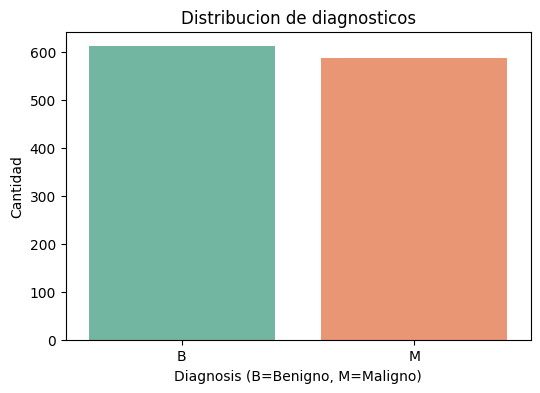

diagnosis
B    0.51
M    0.49
Name: proporcion, dtype: float64


In [22]:
# Distribucion de clases

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="diagnosis", hue="diagnosis", palette="Set2", legend=False)
plt.title("Distribucion de diagnosticos")
plt.xlabel("Diagnosis (B=Benigno, M=Maligno)")
plt.ylabel("Cantidad")
plt.show()

print(df["diagnosis"].value_counts(normalize=True).rename("proporcion"))

# Paso 5: Preprocesamiento

**Que hace:** Convierte la variable objetivo a formato numerico y separa predictores (X) y objetivo (y).

In [23]:
# Codificacion de la variable objetivo y separacion X/y

df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("Dimension de X:", X.shape)
print("Dimension de y:", y.shape)
print("\nDistribucion de y:")
print(y.value_counts())

Dimension de X: (1200, 21)
Dimension de y: (1200,)

Distribucion de y:
diagnosis
0    612
1    588
Name: count, dtype: int64


# Paso 5.1: Correlacion e identificacion de variables redundantes

**Que hace:** Calcula correlaciones entre features para detectar redundancia y apoyar decisiones de seleccion de variables.

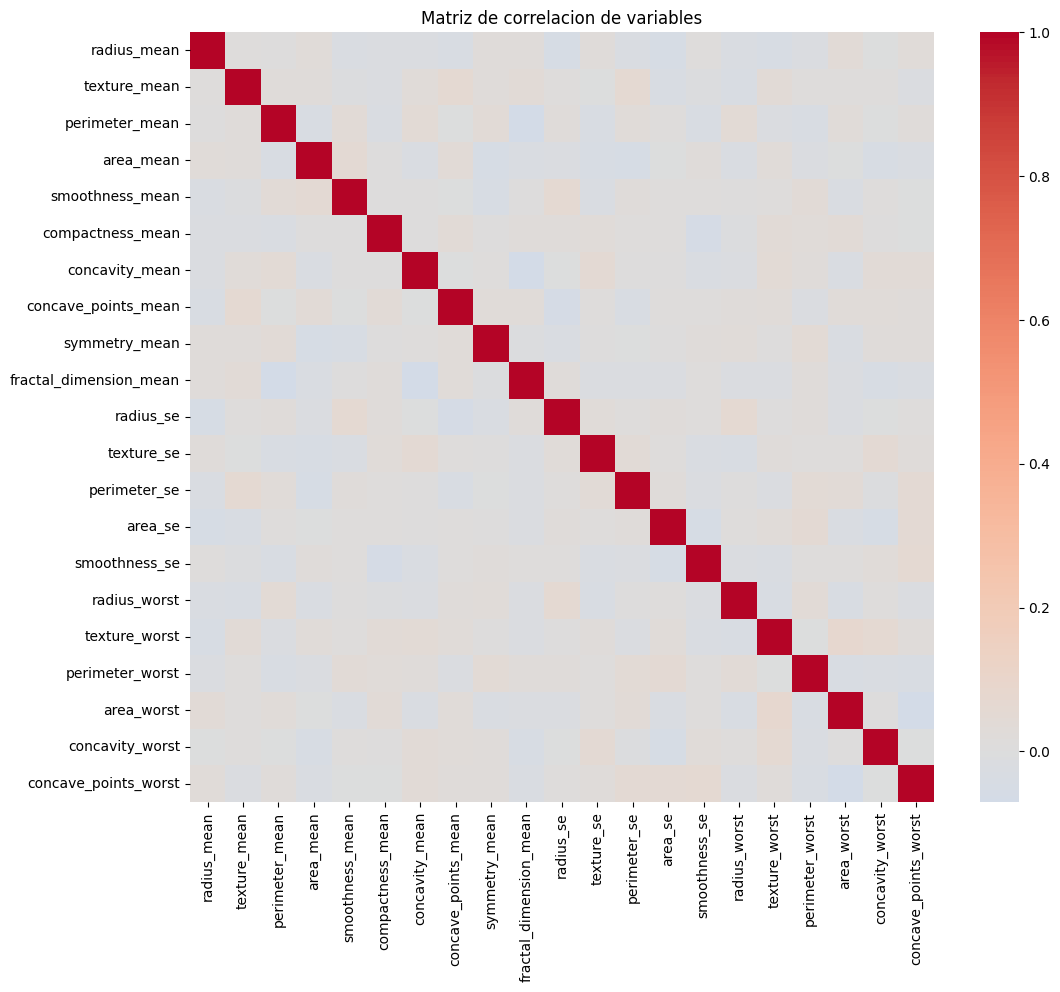

Top pares con correlacion > 0.90:
Series([], dtype: float64)


In [24]:
# Matriz de correlacion y pares altamente correlacionados

corr_matrix = X.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matriz de correlacion de variables")
plt.show()

upper_triangle = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = upper_triangle.stack().sort_values(ascending=False)
high_corr_pairs = high_corr_pairs[high_corr_pairs > 0.9]

print("Top pares con correlacion > 0.90:")
print(high_corr_pairs.head(15))

# Paso 6: Division del dataset

**Que hace:** Divide en train/test con estratificacion para mantener la proporcion de clases.

In [25]:
# Split train/test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (960, 21)
X_test: (240, 21)
y_train: (960,)
y_test: (240,)


# Paso 7: Escalado de datos

**Que hace:** Estandariza variables con StandardScaler para estabilizar el entrenamiento de la red neuronal.

In [26]:
# Escalado

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (960, 21)
X_test_scaled: (240, 21)


# Paso 8: Construccion de la red neuronal (TensorFlow/Keras)

**Que hace:** Define una red secuencial profunda con regularizacion L2 y Dropout para reducir overfitting.

In [27]:
# Arquitectura del modelo

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    Dense(32, activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid"),
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,033 (15.75 KB)

 Trainable params: 4,033 (15.75 KB)

 Non-trainable params: 0 (0.00 B)

# Paso 9: Compilacion del modelo

**Que hace:** Configura optimizador Adam, funcion de perdida binary_crossentropy y metrica accuracy.

In [28]:
# Compilacion

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Paso 10: Entrenamiento con validacion

**Que hace:** Entrena usando validation_split y callbacks (EarlyStopping + ReduceLROnPlateau) para controlar overfitting.

In [29]:
# Entrenamiento

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=120,
    batch_size=16,
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
)

Epoch 1/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4883 - loss: 0.7496 - val_accuracy: 0.4479 - val_loss: 0.7182 - learning_rate: 0.0010
Epoch 2/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5039 - loss: 0.7157 - val_accuracy: 0.4792 - val_loss: 0.7114 - learning_rate: 0.0010
Epoch 3/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5078 - loss: 0.7060 - val_accuracy: 0.5104 - val_loss: 0.7082 - learning_rate: 0.0010
Epoch 4/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5534 - loss: 0.6950 - val_accuracy: 0.4896 - val_loss: 0.7053 - learning_rate: 0.0010
Epoch 5/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5521 - loss: 0.6916 - val_accuracy: 0.5000 - val_loss: 0.7052 - learning_rate: 0.0010
Epoch 6/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5677 - loss: 0.6967 - val_accuracy: 0.5052 - val_loss: 0.7083 - learning_rate: 0.0010
Epoch 7/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5729 - loss: 0.6850 - val_ac

# Paso 11: Evaluacion del modelo

**Que hace:** Evalua el rendimiento sobre test y calcula metricas clinicas: accuracy, precision, recall y F1-score.

In [30]:
# Evaluacion base en test

test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Loss en test: {test_loss:.4f}")
print(f"Accuracy en test: {test_accuracy:.4f}")

Loss en test: 0.7200
Accuracy en test: 0.4542


# Paso 12: Predicciones y metricas clinicas

**Que hace:** Obtiene predicciones y calcula accuracy, precision, recall, F1 y matriz de confusion para analisis medico.

Accuracy : 0.4542
Precision: 0.4454
Recall   : 0.4492
F1-score : 0.4473

Reporte de clasificacion:
              precision    recall  f1-score   support

     Benigno       0.46      0.46      0.46       122
     Maligno       0.45      0.45      0.45       118

    accuracy                           0.45       240
   macro avg       0.45      0.45      0.45       240
weighted avg       0.45      0.45      0.45       240



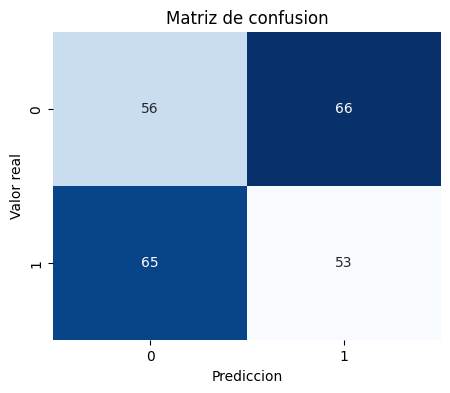

In [31]:
# Predicciones y metricas

y_prob = model.predict(X_test_scaled, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nReporte de clasificacion:")
print(classification_report(y_test, y_pred, target_names=["Benigno", "Maligno"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusion")
plt.xlabel("Prediccion")
plt.ylabel("Valor real")
plt.show()

# Paso 13: Analisis de overfitting e interpretacion

**Que hace:** Visualiza curvas de aprendizaje y explica la importancia clinica de recall en deteccion de cancer.

- **Accuracy:** porcentaje total de aciertos.
- **Precision:** de los casos predichos como malignos, cuantos realmente lo eran.
- **Recall (sensibilidad):** de los malignos reales, cuantos detecto el modelo.  
  En cancer, recall alto es critico para minimizar falsos negativos.
- **F1-score:** balance entre precision y recall.

Si la curva de entrenamiento mejora pero validacion empeora, hay sobreajuste.

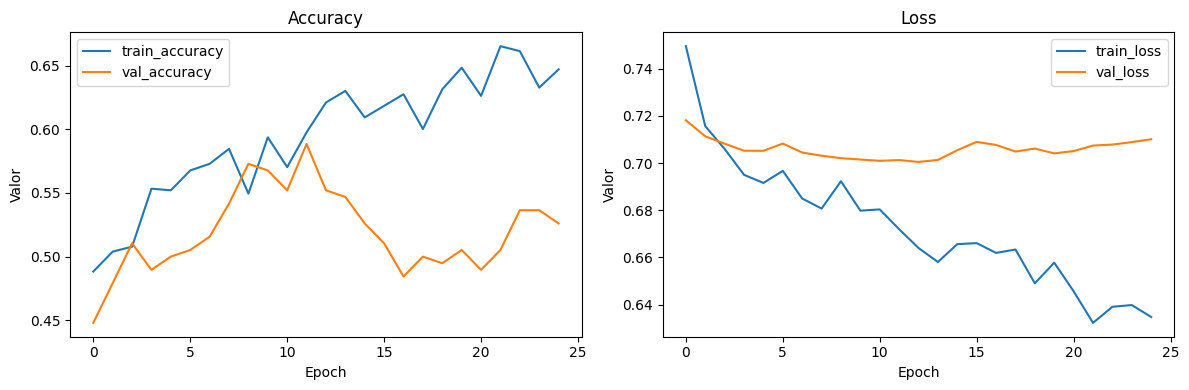

Ultimas epocas registradas:


,accuracy,loss,val_accuracy,val_loss,learning_rate
20,0.626302,0.645623,0.489583,0.705091,0.00050
21,0.665365,0.632220,0.505208,0.707446,0.00050
22,0.661458,0.639047,0.536458,0.707872,0.00050
23,0.632812,0.639782,0.536458,0.708907,0.00025
24,0.647135,0.634730,0.526042,0.710123,0.00025


In [32]:
# Curvas de aprendizaje

history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["accuracy"], label="train_accuracy")
axes[0].plot(history_df["val_accuracy"], label="val_accuracy")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Valor")
axes[0].legend()

axes[1].plot(history_df["loss"], label="train_loss")
axes[1].plot(history_df["val_loss"], label="val_loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Valor")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Ultimas epocas registradas:")
display(history_df.tail())

# Paso 14: Conclusion y mejoras propuestas

**Que hace:** Resume confiabilidad del modelo y sugiere mejoras para robustecer el sistema.

- Si `recall` es alto y cercano al de entrenamiento/validacion, el modelo es mas confiable clinicamente.
- Si hay brecha grande train vs val, aplicar mas regularizacion o reducir complejidad.
- Mejoras sugeridas: ajuste de umbral de decision, calibracion de probabilidades y validacion externa.

# Paso 15: Mejora clinica por ajuste de umbral

**Que hace:** Ajusta el umbral de clasificacion para priorizar recall en la clase maligna y reducir falsos negativos.

In [33]:
# Ajuste de umbral para maximizar recall con precision minima

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

min_precision = 0.40
valid_idx = np.where(precisions[:-1] >= min_precision)[0]

if len(valid_idx) > 0:
    best_idx = valid_idx[np.argmax(recalls[:-1][valid_idx])]
    best_threshold = thresholds[best_idx]
else:
    best_threshold = 0.5

y_pred_tuned = (y_prob >= best_threshold).astype(int)

print(f"Umbral seleccionado: {best_threshold:.4f}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred_tuned):.4f}")

Umbral seleccionado: 0.2300
Accuracy  : 0.4917
Precision : 0.4917
Recall    : 1.0000
F1-score  : 0.6592
